In [1]:
import numpy as np
import matplotlib.pyplot as plt
from h5py import File


In [17]:
with File("/mnt/extraspace/rstiskalek/catalogs/PV_compilation.hdf5", 'r') as f:
    print(f["SFI_gals"].keys())

    zCMB_sfi = f["SFI_gals"]["z_CMB"][...]
    mag_sfi = f["SFI_gals"]["mag"][...]
    eta_sfi = f["SFI_gals"]["eta"][...]
    e_mag_sfi = f["SFI_gals"]["e_mag"][...]
    e_eta_sfi = f["SFI_gals"]["e_eta"][...]

    zCMB_2MTF = f["2MTF"]["z_CMB"][...]
    mag_2MTF = f["2MTF"]["mag"][...]
    eta_2MTF = f["2MTF"]["eta"][...]
    e_mag_2MTF = f["2MTF"]["e_mag"][...]
    e_eta_2MTF = f["2MTF"]["e_eta"][...]

<KeysViewHDF5 ['DEC', 'RA', 'e_eta', 'e_mag', 'eta', 'mag', 'z_CMB']>


In [62]:
!ls /mnt/extraspace/rstiskalek/catalogs/PV/CF4/

CF4_GroupAll.hdf5  CF4_TF-distances.hdf5


In [65]:
with File("/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TF-distances.hdf5", 'r') as f:
    zCMB = f["Vcmb"][...] / 3e5
    rband = f["r"][...]

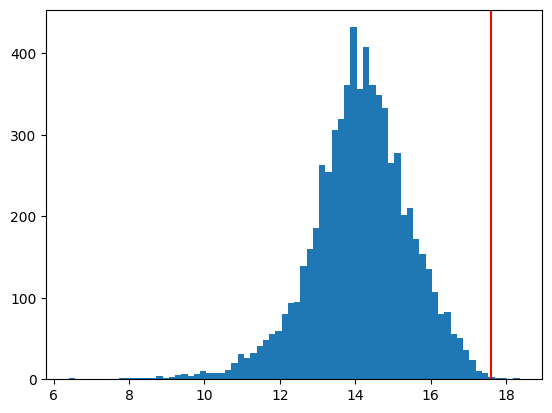

In [69]:
m = rband > 0

plt.figure()
plt.hist(rband[m], bins="auto")
plt.axvline(17.6, c="red")
plt.show()

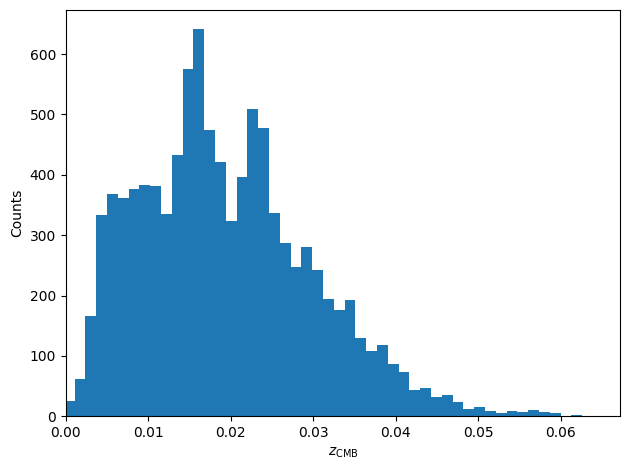

In [64]:
plt.figure()
plt.hist(zCMB, bins="auto")
plt.xlabel(r"$z_{\rm CMB}$")
plt.ylabel("Counts")
plt.xlim(0)
plt.tight_layout()
plt.savefig("../../plots/zCMB_CF4.png")
plt.show()

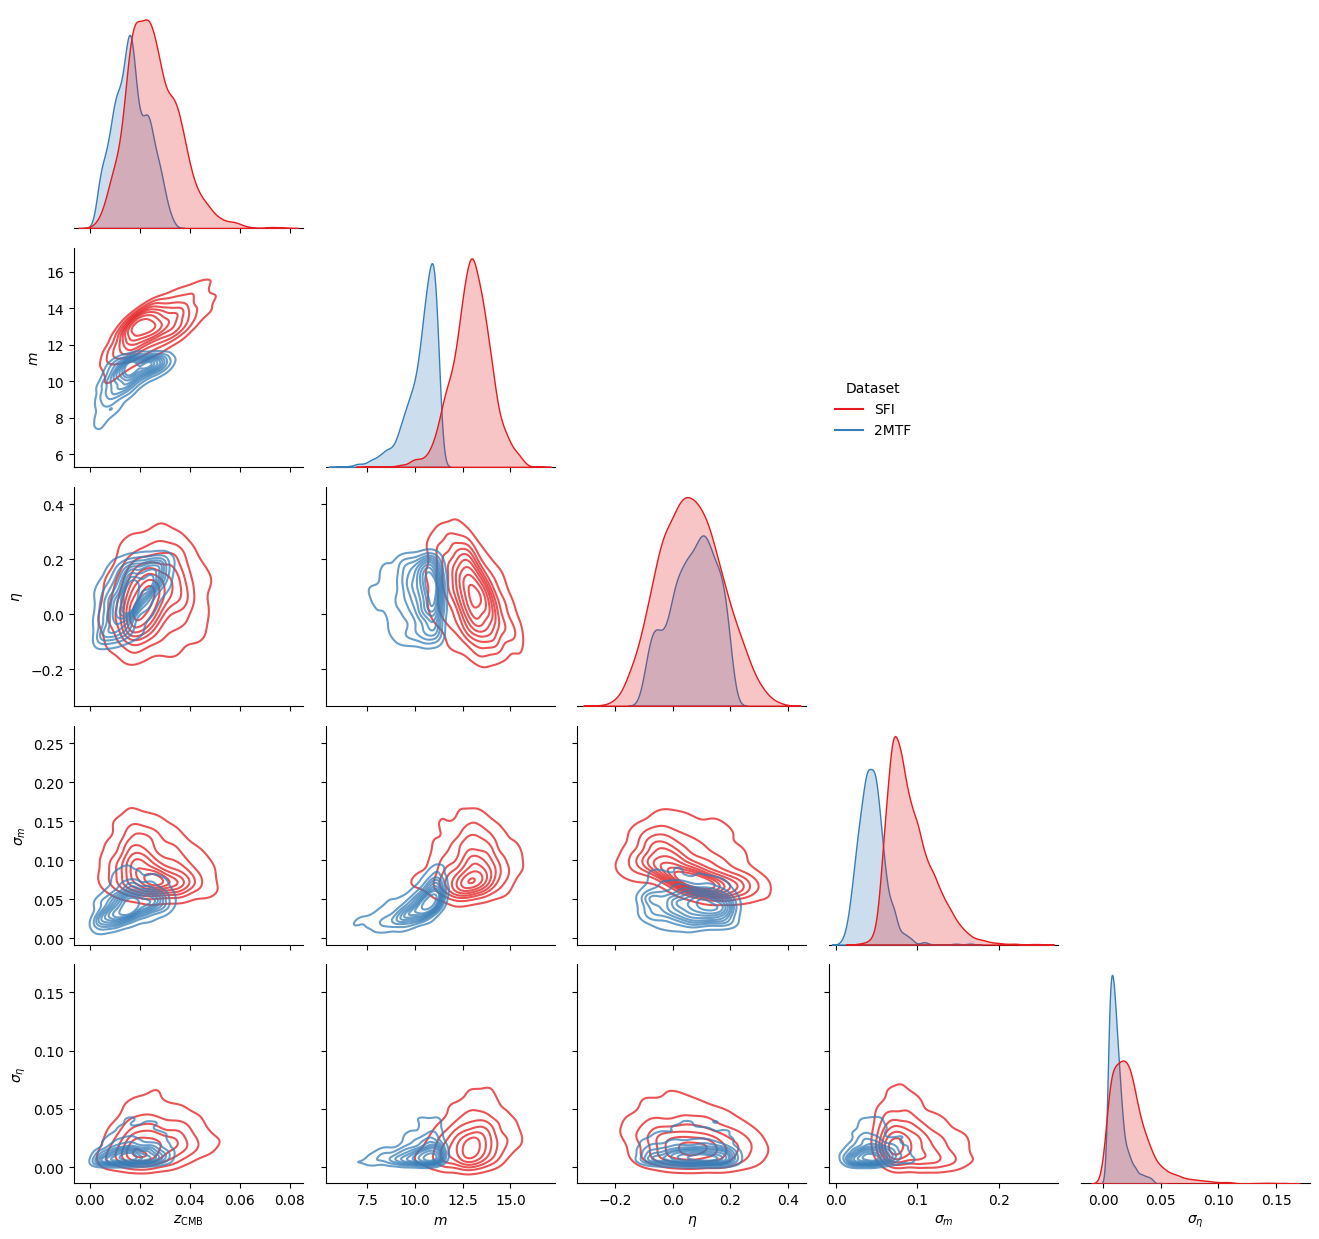

In [53]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df_sfi = pd.DataFrame({
    r"$z_{\rm CMB}$": zCMB_sfi,
    r"$m$": mag_sfi,
    r"$\eta$": eta_sfi,
    r"$\sigma_{m}$": e_mag_sfi,
    r"$\sigma_\eta$": e_eta_sfi,
    "Dataset": "SFI"
})

df_2mtf = pd.DataFrame({
    r"$z_{\rm CMB}$": zCMB_2MTF,
    r"$m$": mag_2MTF,
    r"$\eta$": eta_2MTF,
    r"$\sigma_{m}$": e_mag_2MTF,
    r"$\sigma_\eta$": e_eta_2MTF,
    "Dataset": "2MTF"
})

df_combined = pd.concat([df_sfi, df_2mtf])
g = sns.pairplot(df_combined, hue="Dataset", kind="kde", diag_kind="kde",
             palette="Set1", corner=True, plot_kws={"alpha": 0.75},
             diag_kws={"fill": True})
sns.move_legend(g, "upper right", bbox_to_anchor=(0.7, 0.7))

# Show the plot
plt.tight_layout()
plt.savefig("../../plots/TFR_data.pdf", dpi=450)
plt.show()
